# Data Understanding — Sirio-Libanes ICU (clustering track)

**CRISP-DM phase:** Data Understanding (unsupervised exploration; **no clustering training here**).

## 0. Business understanding (baseline)

- **Source:** Public Sirio-Libanes ICU dataset (Kaggle; COVID era). **One file** lives in this repo at `data/raw/Kaggle_Sirio_Libanes_ICU_Prediction.xlsx` (avoid duplicate copies elsewhere).
- **Unit of analysis:** Each row is a **patient visit × time window** (`WINDOW`: e.g. `0-2`, `2-4`, … hours from ICU admit). The same patient appears on **multiple rows** — that is **longitudinal structure**, not accidental duplication.
- **Goal later:** Cluster **patient × time-window** rows using the **full longitudinal grid** (all five `WINDOW` values — **1,925 rows** in this release).
- **This notebook:** Profiles that grid; **§8 demographics** use one row per patient (`0-2`) so counts are not inflated 5×.
- **Limits:** Severe **missingness** before imputation; labels like `ICU` can be **leakage** if used as a plain feature without careful design — document for modeling.

**Copy governance:**
- **`df_raw`**: full **5-window longitudinal** table = **clustering scope**. Read-only here.
- **`df_demo`**: `WINDOW == '0-2'`, **one row per patient** — **§8 only**.
- §§4–7 use **`df_raw`** directly (no second full copy).

**Five-supervisor framing:** Profiling, quality rules, leakage / cohort choice, high-dimensionality risk, reproducibility — see **§9**.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


## 1. Resolve path and load (`df_raw`)

Run from the **repo root** or from `clustering_sirio_covid_data_set/`. Requires **openpyxl** for `.xlsx`.


In [21]:
candidate_roots = [Path.cwd(), Path.cwd() / 'clustering_sirio_covid_data_set']
RAW_NAME = 'Kaggle_Sirio_Libanes_ICU_Prediction.xlsx'


def _find_raw():
    for root in candidate_roots:
        p = root / 'data' / 'raw' / RAW_NAME
        if p.exists():
            return p
        p = root / RAW_NAME
        if p.exists():
            return p
    return None


raw_path = _find_raw()
if raw_path is None:
    raise FileNotFoundError(
        'Place the Kaggle Excel file at clustering_sirio_covid_data_set/data/raw/' + RAW_NAME
    )

base_dir = raw_path.parent.parent.parent if (raw_path.parent.name == 'raw') else raw_path.parent
print('base_dir:', base_dir.resolve())
print('raw file:', raw_path.resolve())

df_raw = pd.read_excel(raw_path, engine='openpyxl')
N_RAW_ROWS = len(df_raw)
print('df_raw shape:', df_raw.shape)
display(df_raw.head())


base_dir: C:\Users\rahma\Desktop\machine learning project\clustering_sirio_covid_data_set
raw file: C:\Users\rahma\Desktop\machine learning project\clustering_sirio_covid_data_set\data\raw\Kaggle_Sirio_Libanes_ICU_Prediction.xlsx
df_raw shape: (1925, 231)


,PATIENT_VISIT_IDENTIFIER,AGE_ABOVE65,AGE_PERCENTIL,GENDER,DISEASE GROUPING 1,DISEASE GROUPING 2,DISEASE GROUPING 3,DISEASE GROUPING 4,DISEASE GROUPING 5,DISEASE GROUPING 6,...,TEMPERATURE_DIFF,OXYGEN_SATURATION_DIFF,BLOODPRESSURE_DIASTOLIC_DIFF_REL,BLOODPRESSURE_SISTOLIC_DIFF_REL,HEART_RATE_DIFF_REL,RESPIRATORY_RATE_DIFF_REL,TEMPERATURE_DIFF_REL,OXYGEN_SATURATION_DIFF_REL,WINDOW,ICU
0,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0-2,0
1,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,2-4,0
2,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4-6,0
3,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,-1.000000,-1.000000,NaN,NaN,NaN,NaN,-1.000000,-1.000000,6-12,0
4,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,-0.238095,-0.818182,-0.389967,0.407558,-0.230462,0.096774,-0.242282,-0.814433,ABOVE_12,1


,PATIENT_VISIT_IDENTIFIER,AGE_ABOVE65,AGE_PERCENTIL,GENDER,DISEASE GROUPING 1,DISEASE GROUPING 2,DISEASE GROUPING 3,DISEASE GROUPING 4,DISEASE GROUPING 5,DISEASE GROUPING 6,...,TEMPERATURE_DIFF,OXYGEN_SATURATION_DIFF,BLOODPRESSURE_DIASTOLIC_DIFF_REL,BLOODPRESSURE_SISTOLIC_DIFF_REL,HEART_RATE_DIFF_REL,RESPIRATORY_RATE_DIFF_REL,TEMPERATURE_DIFF_REL,OXYGEN_SATURATION_DIFF_REL,WINDOW,ICU
0,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0-2,0
1,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,2-4,0
2,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4-6,0
3,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,-1.000000,-1.000000,NaN,NaN,NaN,NaN,-1.000000,-1.000000,6-12,0
4,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,-0.238095,-0.818182,-0.389967,0.407558,-0.230462,0.096774,-0.242282,-0.814433,ABOVE_12,1


## 2. Longitudinal structure & `WINDOW`

How many patients, how many rows per patient, and how rows split across windows?


Unique patients (PATIENT_VISIT_IDENTIFIER): 385
Average rows per patient: 5.00

WINDOW distribution (all rows):


WINDOW
0-2         385
2-4         385
4-6         385
6-12        385
ABOVE_12    385
Name: count, dtype: int64

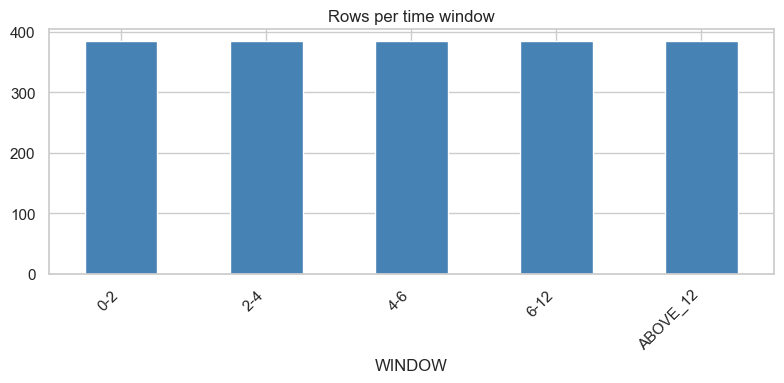

In [22]:
pid = 'PATIENT_VISIT_IDENTIFIER'
n_pat = df_raw[pid].nunique()
print(f'Unique patients ({pid}): {n_pat}')
print(f'Average rows per patient: {len(df_raw) / n_pat:.2f}')
print()
print('WINDOW distribution (all rows):')
display(df_raw['WINDOW'].value_counts().sort_index())
fig, ax = plt.subplots(figsize=(8, 4))
df_raw['WINDOW'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Rows per time window')
ax.set_xlabel('WINDOW')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 3. Missingness — full matrix (`df_raw`)

Clustering prep must confront sparse labs/vitals. Report **global** missing rate and worst columns (no imputation in Data Understanding).


Global missing rate (cells): 50.34%
Columns with >70% missing: 0
Columns with >50% missing: 180


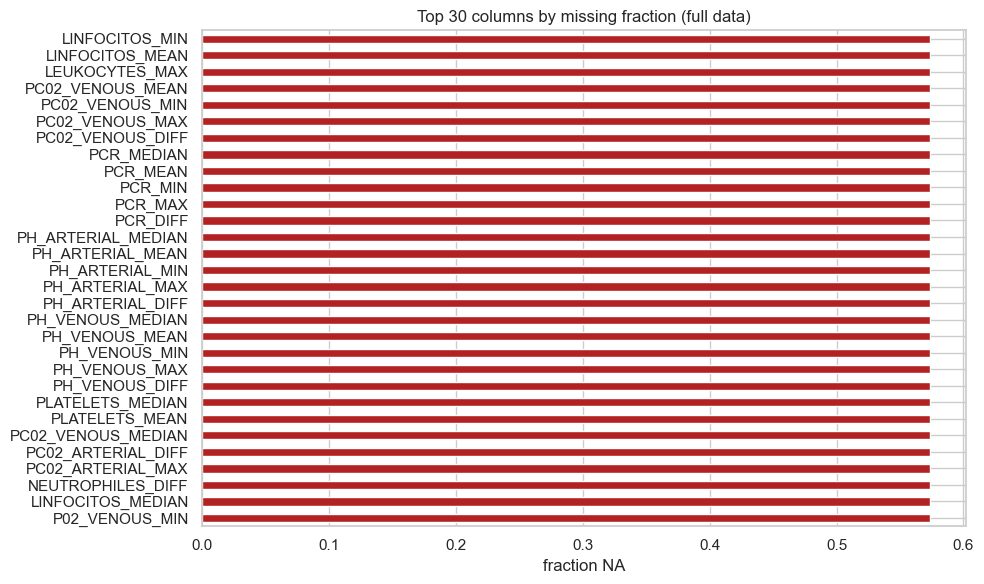

In [23]:
miss_full = df_raw.isna().mean().sort_values(ascending=False)
global_miss = 100 * df_raw.isna().sum().sum() / df_raw.size
print(f'Global missing rate (cells): {global_miss:.2f}%')
print(f'Columns with >70% missing: {(miss_full > 0.7).sum()}')
print(f'Columns with >50% missing: {(miss_full > 0.5).sum()}')

plt.figure(figsize=(10, 6))
miss_full.head(30).sort_values().plot(kind='barh', color='firebrick')
plt.title('Top 30 columns by missing fraction (full data)')
plt.xlabel('fraction NA')
plt.tight_layout()
plt.show()


## 4. Clustering scope & missingness (`df_raw`)

**Decision for Phase 3:** clustering / PCA inputs use the **full longitudinal grid** — every patient window (**1,925 rows**), matching `03b_DataPreparation_Sirio.ipynb` (**no `WINDOW` filter** before imputation).

The table contrasts this scope with a **reference** single-window slice. **Missingness** below is for the **full grid** (the population that goes to prep).


In [24]:
pid = 'PATIENT_VISIT_IDENTIFIER'
N_LONG = len(df_raw)
n_pat = df_raw[pid].nunique()
slice_02 = df_raw['WINDOW'].astype(str) == '0-2'
flow = pd.DataFrame([
    {
        'stage': 'Full 5-window grid (clustering / 03b)',
        'n_rows': N_LONG,
        'n_patients': n_pat,
    },
    {
        'stage': "Reference: WINDOW == '0-2' (1 row/patient)",
        'n_rows': int(slice_02.sum()),
        'n_patients': df_raw.loc[slice_02, pid].nunique(),
    },
])
display(flow)

miss_long = df_raw.isna().mean().sort_values(ascending=False)
print(f"Global missing (cells) on full longitudinal grid: {100 * df_raw.isna().sum().sum() / df_raw.size:.2f}%")


,stage,n_rows,n_patients
0,Full 5-window grid (clustering / 03b),1925,385
1,Reference: WINDOW == '0-2' (1 row/patient),385,385


Global missing (cells) on full longitudinal grid: 50.34%


## 5. Identifiers, duplicates & longitudinal integrity

- **Exact duplicate rows** (all columns) on **`df_raw`**.
- **Rows per patient:** expect **5** on the full grid; **`(patient, WINDOW)`** pairs must be unique.
- Second chart: **rows per `WINDOW`** (expect balance).


Exact duplicate rows — full longitudinal grid: 0
Patients without exactly 5 rows: 0
Rows part of a duplicate (patient, WINDOW) key: 0


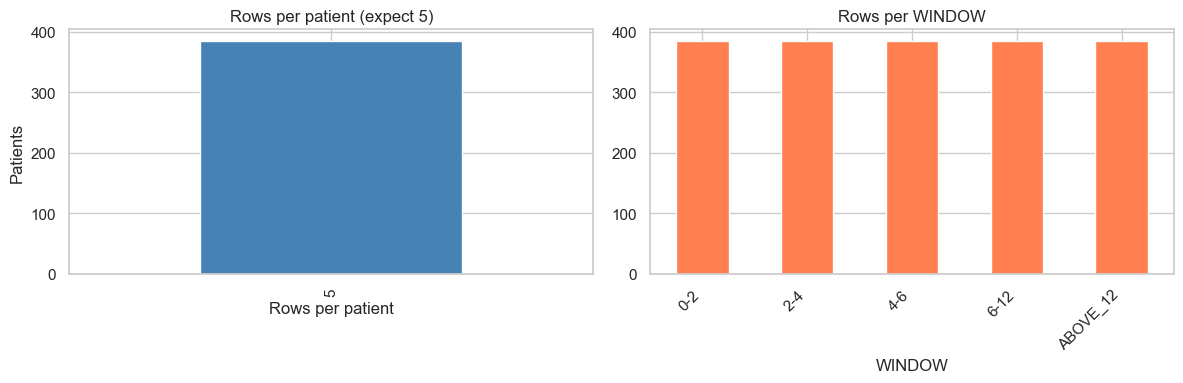

ICU value counts (full longitudinal grid):
ICU
0    1410
1     515
Name: count, dtype: int64


In [25]:
pid = 'PATIENT_VISIT_IDENTIFIER'

dup_full = int(df_raw.duplicated().sum())
print(f'Exact duplicate rows — full longitudinal grid: {dup_full}')

per_full = df_raw.groupby(pid).size()
multi_ne5 = int((per_full != 5).sum())
print(f'Patients without exactly 5 rows: {multi_ne5}')
if multi_ne5:
    display(per_full[per_full != 5].head(20))

dup_key_rows = int(df_raw.duplicated(subset=[pid, 'WINDOW'], keep=False).sum())
print(f'Rows part of a duplicate (patient, WINDOW) key: {dup_key_rows}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
per_full.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rows per patient (expect 5)')
axes[0].set_xlabel('Rows per patient')
axes[0].set_ylabel('Patients')

df_raw['WINDOW'].astype(str).value_counts().reindex(
    ['0-2', '2-4', '4-6', '6-12', 'ABOVE_12']
).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Rows per WINDOW')
axes[1].set_xlabel('WINDOW')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

if 'ICU' in df_raw.columns:
    print('ICU value counts (full longitudinal grid):')
    print(df_raw['ICU'].value_counts(dropna=False))


## 6. Outlier pilot (`df_raw`, exploratory)

**Tukey fences** (1.5×IQR) on numerics with ≥ **50%** observed across **all windows**. **No removal** in DU.

Boxplots: clinical medians + lowest Tukey-rate continuous columns (IQR > 0).


Top columns by Tukey outlier rate (full longitudinal grid):


RESPIRATORY_RATE_DIFF               0.140187
RESPIRATORY_RATE_DIFF_REL           0.129992
RESPIRATORY_RATE_MEDIAN             0.107052
RESPIRATORY_RATE_MAX                0.095157
RESPIRATORY_RATE_MEAN               0.087511
OXYGEN_SATURATION_DIFF_REL          0.062147
OXYGEN_SATURATION_MIN               0.060533
OXYGEN_SATURATION_DIFF              0.059726
BLOODPRESSURE_SISTOLIC_DIFF         0.058871
BLOODPRESSURE_SISTOLIC_DIFF_REL     0.054032
BLOODPRESSURE_DIASTOLIC_DIFF        0.050000
BLOODPRESSURE_DIASTOLIC_DIFF_REL    0.050000
RESPIRATORY_RATE_MIN                0.040782
HEART_RATE_DIFF                     0.035484
HEART_RATE_DIFF_REL                 0.033065
dtype: float64

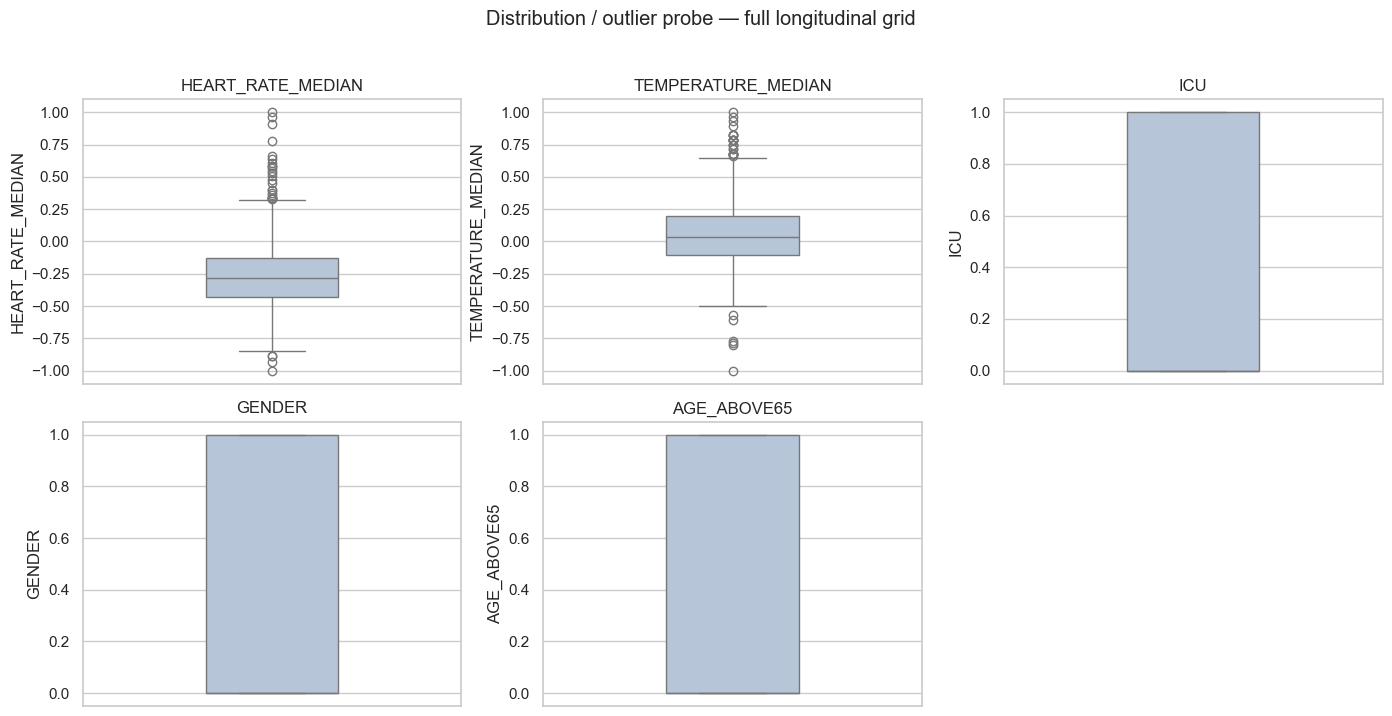

In [26]:
pid = 'PATIENT_VISIT_IDENTIFIER'
num = df_raw.select_dtypes(include=[np.number]).columns.tolist()
if pid in num:
    num.remove(pid)

min_obs_frac = 0.50
usable = [c for c in num if df_raw[c].notna().mean() >= min_obs_frac]

outlier_rates = {}
for c in usable:
    s = df_raw[c].dropna()
    if len(s) < 20:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = float(q3 - q1)
    if iqr == 0:
        continue
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    m = (df_raw[c] < lo) | (df_raw[c] > hi)
    outlier_rates[c] = float(m.sum() / df_raw[c].notna().sum())

orate = pd.Series(outlier_rates).sort_values(ascending=False)
print('Top columns by Tukey outlier rate (full longitudinal grid):')
display(orate.head(15))

plot_cols = []
for c in ['HEART_RATE_MEDIAN', 'TEMPERATURE_MEDIAN', 'MEAN_BLOOD_PRESSURE_MEDIAN']:
    if c in df_raw.columns and df_raw[c].notna().sum() >= 30:
        plot_cols.append(c)
if len(orate):
    plot_cols.extend(orate.sort_values().head(3).index.tolist())
seen = []
for c in plot_cols:
    if c not in seen:
        seen.append(c)
plot_cols = seen[:6]

if plot_cols:
    n = len(plot_cols)
    nrow = (n + 2) // 3
    fig, axes = plt.subplots(nrow, 3, figsize=(14, 3.5 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, plot_cols):
        sns.boxplot(y=df_raw[col], ax=ax, color='lightsteelblue', width=0.35)
        ax.set_title(col[:45])
    for j in range(len(plot_cols), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Distribution / outlier probe — full longitudinal grid', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No column met plotting thresholds.')


## 7. Correlation pilot (numeric, low missing on `df_raw`)

Up to **20** lowest-missing numeric columns on the **full grid**; **Spearman** heatmap on complete cases.


Columns in heatmap: 20 | complete-case rows: 1223


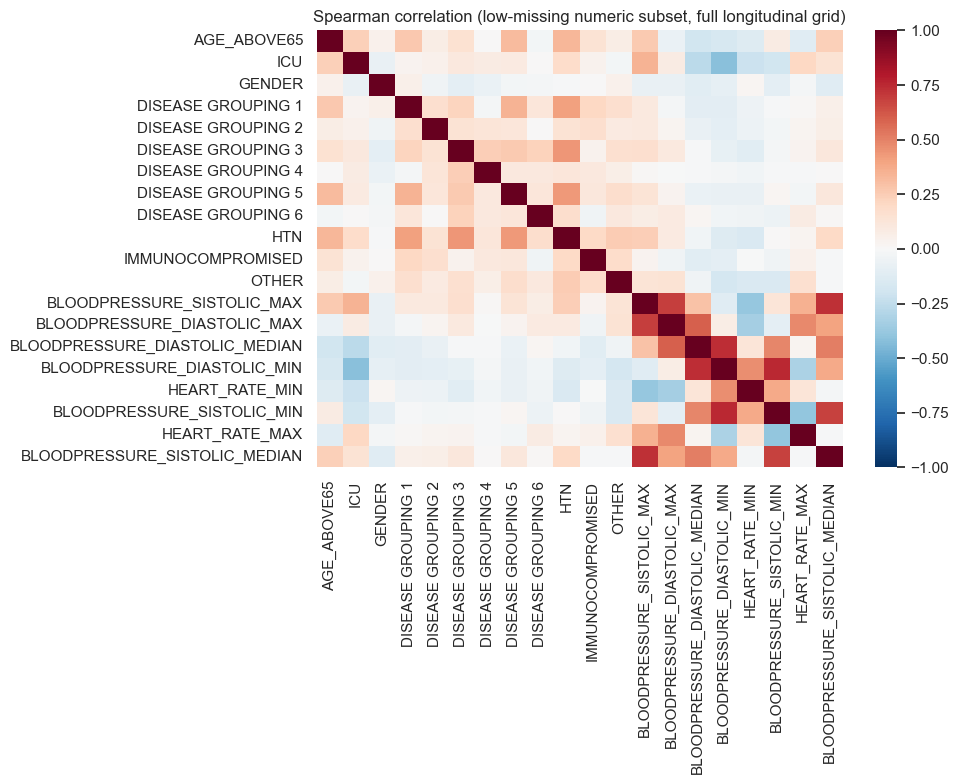

In [27]:
pid = 'PATIENT_VISIT_IDENTIFIER'
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
if pid in num_cols:
    num_cols.remove(pid)

miss_num = miss_long.reindex(num_cols).dropna()
low_miss_cols = miss_num.sort_values().index[: min(20, len(miss_num))]
sub = df_raw[low_miss_cols].dropna(axis=0, how='any')
print(f'Columns in heatmap: {len(low_miss_cols)} | complete-case rows: {len(sub)}')

if len(sub) >= 5:
    cm = sub.corr(method='spearman')
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
    plt.title('Spearman correlation (low-missing numeric subset, full longitudinal grid)')
    plt.tight_layout()
    plt.show()
else:
    print('Too few complete rows for correlation heatmap.')


## 8. Demographics — patient level (`df_demo`)

**One row per patient** (`WINDOW == '0-2'`) so bar charts are not dominated by five repeated patient records.


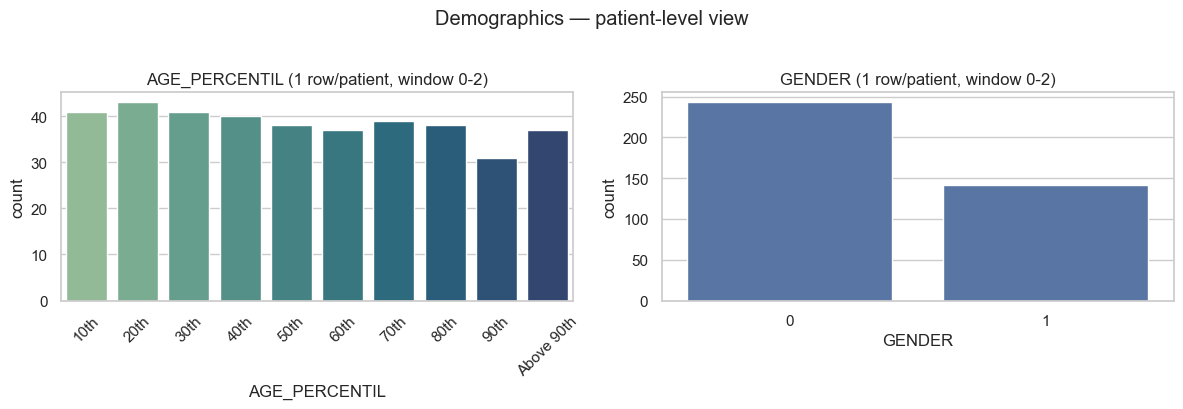

In [28]:
pid = 'PATIENT_VISIT_IDENTIFIER'
df_demo = df_raw.loc[df_raw['WINDOW'].astype(str) == '0-2'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if 'AGE_PERCENTIL' in df_demo.columns:
    ord_age = sorted(df_demo['AGE_PERCENTIL'].dropna().astype(str).unique())
    sns.countplot(data=df_demo, x='AGE_PERCENTIL', order=ord_age, ax=axes[0], palette='crest')
    axes[0].set_title('AGE_PERCENTIL (1 row/patient, window 0-2)')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].set_visible(False)

if 'GENDER' in df_demo.columns:
    sns.countplot(data=df_demo, x='GENDER', ax=axes[1])
    axes[1].set_title('GENDER (1 row/patient, window 0-2)')
else:
    axes[1].set_visible(False)

plt.suptitle('Demographics — patient-level view', y=1.02)
plt.tight_layout()
plt.show()


## 9. Five-supervisor synthesis — Data Understanding

| Supervisor | Role | Focus | Pass / questions |
|------------|------|-------|-------------------|
| **1** | Profiling | Missingness on **full grid** | ~50% cells NA; **180** columns >50% NA — longitudinal **ffill/bfill** + residual fill in `03b` is required. |
| **2** | Quality | Longitudinal keys | **5** rows/patient; balanced windows; **0** duplicate `(patient, WINDOW)` keys expected. |
| **3** | ML / leakage | `ICU` | **`ICU` excluded from `X` in `03b`** for clustering; use only for external validation if needed. |
| **4** | Dimensionality | 231 → PCA | Pilot correlation is **subset-only**; redundant lab summaries support **PCA** in prep. |
| **5** | MLOps | Scope & files | Single `data/raw/` file; **`metadata.json`** from `03b` records **full longitudinal** row counts. |

**DU coverage:** full-grid missingness, integrity **with charts**, Tukey outliers on **full grid**, Spearman on **full grid**, patient-level demographics in **§8**. **No** imputation here.

### Hand-off to Data Preparation (`03b`)

- **Locked:** Clustering rows = **full 5-window longitudinal** (**1,925**). `03b` already processes **all** windows — **no `WINDOW` filter**.
- **Pipeline:** within-patient **ffill/bfill** → residual **median** (numerics) → age encoding → drop IDs / `WINDOW` / `ICU` → **StandardScaler** → **PCA (95% variance)** → `X_scaled`, `X_pca`, **`metadata.json`**.

### Next moves

1. Run **`03b_DataPreparation_Sirio.ipynb`**; verify **`metadata.json`** lists **1925** feature rows.
2. In **`03c`**, treat cluster assignments as **window-specific** (same patient may move across clusters over time).
3. Optional: duplicate prep on **`0-2`** only as a **labeled sensitivity** run — not the main thesis unless you say so.


In [29]:
# Columns available for Phase 3 feature selection
print('Total columns:', len(df_raw.columns))
print(list(df_raw.columns[:25]), '...')


Total columns: 231
['PATIENT_VISIT_IDENTIFIER', 'AGE_ABOVE65', 'AGE_PERCENTIL', 'GENDER', 'DISEASE GROUPING 1', 'DISEASE GROUPING 2', 'DISEASE GROUPING 3', 'DISEASE GROUPING 4', 'DISEASE GROUPING 5', 'DISEASE GROUPING 6', 'HTN', 'IMMUNOCOMPROMISED', 'OTHER', 'ALBUMIN_MEDIAN', 'ALBUMIN_MEAN', 'ALBUMIN_MIN', 'ALBUMIN_MAX', 'ALBUMIN_DIFF', 'BE_ARTERIAL_MEDIAN', 'BE_ARTERIAL_MEAN', 'BE_ARTERIAL_MIN', 'BE_ARTERIAL_MAX', 'BE_ARTERIAL_DIFF', 'BE_VENOUS_MEDIAN', 'BE_VENOUS_MEAN'] ...
